# Hazard CONUS Grid - Hail x Solar - Selected-Cell M2-M4 Smoke Test

**Peril:** hail - **Asset:** canonical solar - **Product:** `hazard_conus_grid`

This notebook is the next step after the selected-cell M1 pilot. It takes the four-cell MRMS-only M1 layer
and proves that the downstream asset engine can consume it:

```text
selected-cell M1 hazard layer
  -> M2 solar coupling, using canonical 100 MW solar footprint
  -> M3 hail damage curve, using the existing capex-weighted solar curve
  -> M4 annual loss simulation and risk-metric readouts
```

## Step back - what this is and is not

This is an **interface smoke test**, not final hail risk.

Why it is useful now:

- it proves the grid M1 layer can drive the same M2-M4 engine shape as the deep Hayhurst asset work;
- it keeps frequency and severity separate until the Monte Carlo;
- it verifies AEP/OEP, PML/VaR, EAL, percent-of-TIV, and zero-risk/no-data handling on four inspectable
  cells.

Why it is not reportable yet:

- M1 is only MRMS daily MESH from 2024-04-01 to 2024-06-30;
- `lambda_cell` is annualized from a short pilot window;
- the count model is a Poisson placeholder because Fano/NegBin cannot be fit from one partial season;
- the event footprint proxy is clipped severe native-pixel area inside the cell, not a full storm footprint;
- severity uses raw daily cell-max MESH, not de-biased or EVT-extended hail size;
- no financial terms, limits, deductibles, or business interruption are included.

Plan links:

- [`docs/plans/hazard_conus_grid/hail/pilot.md`](../../../../../docs/plans/hazard_conus_grid/hail/pilot.md)
- [`docs/plans/hazard_conus_grid/output_schema.md`](../../../../../docs/plans/hazard_conus_grid/output_schema.md)
- [`docs/extra/discussion/conus_grid/assumptions.md`](../../../../../docs/extra/discussion/conus_grid/assumptions.md)

## 0 - Imports, paths, and fixed canonical solar assumptions

Canonical grid exposure follows the CONUS-grid discussion:

- capacity: 100 MW solar;
- dense areal footprint: 1.5 km2;
- TIV basis: 1,483 USD/kWp, inherited from the Hayhurst asset value per kW;
- gross physical damage only.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
HAIL_GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "hail"
SOLAR_GRID_DIR = HAIL_GRID_DIR / "solar"
SOLAR_GRID_DIR.mkdir(parents=True, exist_ok=True)

M1_VERSION = "v2026_06_16"
SMOKE_VERSION = "v2026_06_16"

M1_LAYER_CSV = HAIL_GRID_DIR / f"m1_selected_cell_hazard_layer_{M1_VERSION}.csv"
DAILY_PANEL_CSV = HAIL_GRID_DIR / f"m1_selected_cell_daily_panel_{M1_VERSION}.csv"
DAMAGE_CURVE_JSON = ROOT / "data" / "hail" / "damage_curves" / "hail_solar_asset_capex_weighted.json"

M2_EVENT_SET_CSV = SOLAR_GRID_DIR / f"m2_solar_smoke_event_set_{SMOKE_VERSION}.csv"
M4_METRICS_CSV = SOLAR_GRID_DIR / f"m4_solar_smoke_risk_metrics_{SMOKE_VERSION}.csv"
M4_METRICS_JSON = SOLAR_GRID_DIR / f"m4_solar_smoke_risk_metrics_{SMOKE_VERSION}.json"
M4_ANNUAL_VECTORS_PARQUET = SOLAR_GRID_DIR / f"m4_solar_smoke_annual_vectors_{SMOKE_VERSION}.parquet"

CANONICAL_SOLAR = {
    "asset_type": "solar",
    "capacity_mw": 100.0,
    "asset_area_km2": 1.5,
    "tiv_usd_per_kwp": 1483.0,
}
CANONICAL_SOLAR["tiv_usd"] = (
    CANONICAL_SOLAR["capacity_mw"] * 1000.0 * CANONICAL_SOLAR["tiv_usd_per_kwp"]
)

MC_YEARS = 250_000
SEED = 20260616
RETURN_PERIODS = [2, 5, 10, 25, 50, 100, 200, 250, 500]

print(f"M1 layer: {M1_LAYER_CSV}")
print(f"Daily panel: {DAILY_PANEL_CSV}")
print(
    "canonical solar: "
    f"{CANONICAL_SOLAR['capacity_mw']:.0f} MW, "
    f"{CANONICAL_SOLAR['asset_area_km2']:.1f} km2, "
    f"TIV ${CANONICAL_SOLAR['tiv_usd']/1e6:.1f}M"
)

M1 layer: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/m1_selected_cell_hazard_layer_v2026_06_16.csv
Daily panel: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/m1_selected_cell_daily_panel_v2026_06_16.csv
canonical solar: 100 MW, 1.5 km2, TIV $148.3M


## 1 - Load M1 inputs

The M1 summary layer gives one row per selected cell. The daily panel gives the observed hail-day samples
that become the pilot event sample for M2-M4.

In [2]:
m1 = pd.read_csv(M1_LAYER_CSV)
panel = pd.read_csv(DAILY_PANEL_CSV, parse_dates=["date"])

required_m1 = {
    "hazard",
    "cell_id",
    "role",
    "lat_center",
    "lon_center",
    "lambda_cell",
    "lambda_cell_basis",
    "freq_dist",
    "freq_fit_status",
    "n_hail_days",
    "n_zero_severe_days",
    "sparse_cell_flag",
    "zero_hail_flag",
}
required_panel = {
    "cell_id",
    "role",
    "date",
    "n_native_pixels_observed",
    "n_native_pixels_severe",
    "severe_area_km2_approx",
    "mesh_max_mm",
    "mesh_mean_severe_mm",
    "mesh_p50_mm",
    "mesh_p90_mm",
    "mesh_p95_mm",
    "hail_day_flag",
}
missing_m1 = sorted(required_m1 - set(m1.columns))
missing_panel = sorted(required_panel - set(panel.columns))
assert not missing_m1, f"M1 layer missing columns: {missing_m1}"
assert not missing_panel, f"daily panel missing columns: {missing_panel}"

display(
    m1[
        [
            "role",
            "cell_id",
            "state_abbr",
            "lambda_cell",
            "n_hail_days",
            "n_zero_severe_days",
            "freq_dist",
            "freq_fit_status",
        ]
    ]
)

print(f"daily panel rows: {len(panel):,} ({panel.cell_id.nunique()} cells x {panel.date.nunique()} days)")
print("Takeaway: M1 gives the frequency interface, while the daily panel gives the empirical severity/event sample.")

,role,cell_id,state_abbr,lambda_cell,n_hail_days,n_zero_severe_days,freq_dist,freq_fit_status
0,high_hail,329354,TX,48.164835,12,79,poisson_placeholder,not_fit_single_partial_season; interface_place...
1,medium_hail,261700,MN,8.027473,2,89,poisson_placeholder,not_fit_single_partial_season; interface_place...
2,low_hail,247197,WA,0.000000,0,91,poisson_placeholder,not_fit_single_partial_season; interface_place...
3,hayhurst_reference,336544,TX,8.027473,2,89,poisson_placeholder,not_fit_single_partial_season; interface_place...


daily panel rows: 364 (4 cells x 91 days)
Takeaway: M1 gives the frequency interface, while the daily panel gives the empirical severity/event sample.


## 2 - M2 coupling for canonical solar

For the smoke test, each selected-cell hail day is treated as one event sample. The footprint proxy is:

```text
F_proxy = severe native-pixel area inside the 0.25 degree cell
A_proxy = observed native-pixel area inside the cell
p_hit = min((sqrt(F_proxy) + sqrt(s_solar))^2 / A_proxy, 1)
```

This is the same areal hit-or-miss logic as the Hayhurst M2 notebook, adapted to a gridded cell-day
artifact. The limitation is important: `F_proxy` is clipped to the cell and is not a connected storm
footprint. This is acceptable for the smoke test because the goal is to prove the interface, not final
coupling accuracy.

In [3]:
hail_events = panel.loc[panel["hail_day_flag"].astype(bool)].copy()
hail_events = hail_events.sort_values(["cell_id", "date"]).reset_index(drop=True)
hail_events["event_id"] = (
    "cell_"
    + hail_events["cell_id"].astype(str)
    + "_"
    + hail_events["date"].dt.strftime("%Y%m%d")
)

asset_area = CANONICAL_SOLAR["asset_area_km2"]
footprint = hail_events["severe_area_km2_approx"].astype(float).clip(lower=0.0)
cell_area = hail_events["n_native_pixels_observed"].astype(float).clip(lower=1.0)
hail_events["cell_area_km2_proxy"] = cell_area
hail_events["footprint_area_km2_proxy"] = footprint
hail_events["p_hit_solar"] = np.minimum((np.sqrt(footprint) + math.sqrt(asset_area)) ** 2 / cell_area, 1.0)
hail_events["m2_coupling_basis"] = (
    "Minkowski areal hit-or-miss using severe native-pixel area clipped to cell"
)

display(
    hail_events[
        [
            "role",
            "cell_id",
            "date",
            "n_native_pixels_severe",
            "footprint_area_km2_proxy",
            "cell_area_km2_proxy",
            "p_hit_solar",
            "mesh_max_mm",
        ]
    ].sort_values(["role", "date"])
)

print(f"hail-day event samples: {len(hail_events)}")
print(
    "Takeaway: p_hit_solar is an asset overlap probability for a cell-day sample; it is not a loss multiplier."
)

,role,cell_id,date,n_native_pixels_severe,footprint_area_km2_proxy,cell_area_km2_proxy,p_hit_solar,mesh_max_mm
14,hayhurst_reference,336544,2024-05-16,2,2.0,625.0,0.011143,25.9
15,hayhurst_reference,336544,2024-06-02,14,14.0,625.0,0.039464,33.3
2,high_hail,329354,2024-04-08,1,1.0,625.0,0.007919,26.9
3,high_hail,329354,2024-04-09,211,211.0,625.0,0.396929,67.8
4,high_hail,329354,2024-04-26,1,1.0,625.0,0.007919,25.6
5,high_hail,329354,2024-05-02,13,13.0,625.0,0.037331,31.3
6,high_hail,329354,2024-05-03,1,1.0,625.0,0.007919,25.5
7,high_hail,329354,2024-05-04,3,3.0,625.0,0.013988,28.3
8,high_hail,329354,2024-05-16,1,1.0,625.0,0.007919,25.8
9,high_hail,329354,2024-05-29,335,335.0,625.0,0.610133,105.8


hail-day event samples: 16
Takeaway: p_hit_solar is an asset overlap probability for a cell-day sample; it is not a loss multiplier.


## 3 - M3 damage for canonical solar

We reuse the existing hail x solar capex-weighted damage curve. The intensity is daily cell-max MESH
because that is the selected-cell M1 size-distribution basis. That makes this a stress-test severity input;
later M1 work should de-bias MESH and decide whether max, percentile, or fitted size distribution is the
correct sampling basis.

,role,cell_id,date,mesh_max_mm,damage_ratio,conditional_loss_usd,p_hit_solar
9,high_hail,329354,2024-05-29,105.8,0.336107,49844681.18,0.610133
3,high_hail,329354,2024-04-09,67.8,0.221750,32885524.93,0.396929
13,high_hail,329354,2024-06-11,50.7,0.088534,13129585.68,0.110113
1,medium_hail,261700,2024-06-13,37.3,0.027201,4033918.88,0.085439
15,hayhurst_reference,336544,2024-06-02,33.3,0.018335,2719146.14,0.039464
5,high_hail,329354,2024-05-02,31.3,0.014993,2223445.56,0.037331
11,high_hail,329354,2024-06-07,30.8,0.014252,2113616.91,0.021600
12,high_hail,329354,2024-06-10,30.8,0.014252,2113616.91,0.037331
7,high_hail,329354,2024-05-04,28.3,0.011044,1637814.80,0.013988
2,high_hail,329354,2024-04-08,26.9,0.009564,1418268.11,0.007919


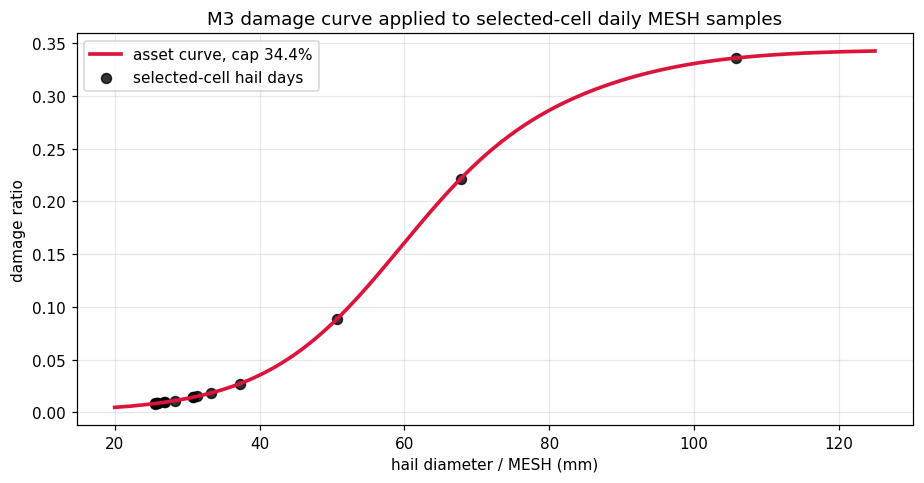

damage curve: hail/solar__asset__capex_weighted | cap 34.4% of TIV | TIV $148.3M
Takeaway: M3 emits full conditional loss if hit; p_hit remains separate for the Monte Carlo.


In [4]:
curve = json.loads(DAMAGE_CURVE_JSON.read_text())
subsystems = curve["subsystems"]


def logistic(x: np.ndarray | float, L: float, k: float, x0: float) -> np.ndarray:
    return L / (1.0 + np.exp(-k * (np.asarray(x, dtype="float64") - x0)))


def damage_ratio(size_mm: np.ndarray | float) -> np.ndarray:
    return sum(
        s["capex_weight"] * logistic(size_mm, s["L"], s["k"], s["x0"])
        for s in subsystems
    )


curve_cap = float(sum(s["capex_weight"] * s["L"] for s in subsystems))
hail_events["damage_ratio"] = damage_ratio(hail_events["mesh_max_mm"].astype(float))
hail_events["conditional_loss_usd"] = (
    hail_events["damage_ratio"] * CANONICAL_SOLAR["tiv_usd"]
).round(2)
hail_events["conditional_loss_pct_tiv"] = hail_events["damage_ratio"]
hail_events["m3_damage_basis"] = (
    "capex-weighted solar PV/tracker damage curve applied to raw daily cell-max MESH"
)

display(
    hail_events[
        [
            "role",
            "cell_id",
            "date",
            "mesh_max_mm",
            "damage_ratio",
            "conditional_loss_usd",
            "p_hit_solar",
        ]
    ].sort_values("conditional_loss_usd", ascending=False)
)

grid = np.linspace(20, 125, 300)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(grid, damage_ratio(grid), color="crimson", lw=2.4, label=f"asset curve, cap {curve_cap:.1%}")
if len(hail_events):
    ax.scatter(
        hail_events["mesh_max_mm"],
        hail_events["damage_ratio"],
        s=42,
        color="black",
        alpha=0.8,
        label="selected-cell hail days",
    )
ax.set(
    title="M3 damage curve applied to selected-cell daily MESH samples",
    xlabel="hail diameter / MESH (mm)",
    ylabel="damage ratio",
)
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"damage curve: {curve['curve_id']} | cap {curve_cap:.1%} of TIV | "
    f"TIV ${CANONICAL_SOLAR['tiv_usd']/1e6:.1f}M"
)
print("Takeaway: M3 emits full conditional loss if hit; p_hit remains separate for the Monte Carlo.")

## 4 - Helper functions for M4 metrics

M4 follows the same discipline as the deep Hayhurst notebook:

- draw annual event counts;
- sample observed event rows;
- flip Bernoulli hit/miss using `p_hit_solar`;
- apply the full conditional loss on hit;
- sum annual total loss for AEP and take annual max occurrence for OEP;
- cap annual aggregate loss at TIV, while separately checking the uncapped analytic mean;
- read metrics from those annual vectors.

In [5]:
def weighted_quantile(values: np.ndarray, weights: np.ndarray, q: float) -> float:
    values = np.asarray(values, dtype="float64")
    weights = np.asarray(weights, dtype="float64")
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not mask.any():
        return float("nan")
    values = values[mask]
    weights = weights[mask]
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cum = np.cumsum(weights)
    cutoff = q * cum[-1]
    return float(values[np.searchsorted(cum, cutoff, side="left")])


def run_cell_mc(
    events: pd.DataFrame,
    lambda_cell: float,
    n_years: int,
    tiv_usd: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    counts = rng.poisson(max(lambda_cell, 0.0), n_years)
    total = int(counts.sum())
    if total == 0 or events.empty:
        z = np.zeros(n_years)
        return z, z, z, counts

    p_evt = events["p_hit_solar"].to_numpy(dtype="float64")
    loss_evt = events["conditional_loss_usd"].to_numpy(dtype="float64")

    idx = rng.integers(0, len(events), total)
    hit = rng.random(total) < p_evt[idx]
    hit_loss = np.where(hit, loss_evt[idx], 0.0)
    year_id = np.repeat(np.arange(n_years), counts)

    aep_uncapped = np.bincount(year_id, weights=hit_loss, minlength=n_years)
    aep = np.minimum(aep_uncapped, tiv_usd)
    oep = np.zeros(n_years)
    if total:
        np.maximum.at(oep, year_id, hit_loss)
    return aep, oep, aep_uncapped, counts


def exceedance_metrics(aep: np.ndarray, oep: np.ndarray, tiv_usd: float) -> dict[str, float]:
    out: dict[str, float] = {}
    out["eal_usd"] = float(np.mean(aep))
    out["eal_pct_tiv"] = out["eal_usd"] / tiv_usd
    out["eal_usd_per_kwp_yr"] = out["eal_usd"] / (CANONICAL_SOLAR["capacity_mw"] * 1000.0)
    out["zero_loss_fraction"] = float(np.mean(aep == 0))

    for rp in RETURN_PERIODS:
        q = 1.0 - 1.0 / rp
        out[f"aep_loss_rp{rp}_usd"] = float(np.quantile(aep, q))
        out[f"oep_loss_rp{rp}_usd"] = float(np.quantile(oep, q))
        out[f"aep_loss_rp{rp}_pct_tiv"] = out[f"aep_loss_rp{rp}_usd"] / tiv_usd
        out[f"oep_loss_rp{rp}_pct_tiv"] = out[f"oep_loss_rp{rp}_usd"] / tiv_usd

    for c in [0.95, 0.99, 0.995, 0.996, 0.998]:
        label = str(c).replace("0.", "")
        out[f"var_aep_{label}_usd"] = float(np.quantile(aep, c))
        out[f"var_oep_{label}_usd"] = float(np.quantile(oep, c))
        out[f"var_aep_{label}_pct_tiv"] = out[f"var_aep_{label}_usd"] / tiv_usd
        out[f"var_oep_{label}_pct_tiv"] = out[f"var_oep_{label}_usd"] / tiv_usd

    for c in [0.95, 0.99]:
        label = str(c).replace("0.", "")
        threshold = float(np.quantile(aep, c))
        tail = aep[aep >= threshold]
        out[f"tvar_aep_{label}_usd"] = float(tail.mean()) if len(tail) else 0.0
        out[f"tvar_aep_{label}_pct_tiv"] = out[f"tvar_aep_{label}_usd"] / tiv_usd

    for threshold_pct in [0.01, 0.05, 0.10, 0.25]:
        label = int(threshold_pct * 100)
        out[f"prob_annual_loss_gt_{label}pct_tiv"] = float(np.mean(aep > threshold_pct * tiv_usd))

    out["pml_aep_rp100_usd"] = out["aep_loss_rp100_usd"]
    out["pml_aep_rp200_usd"] = out["aep_loss_rp200_usd"]
    out["pml_aep_rp250_usd"] = out["aep_loss_rp250_usd"]
    out["pml_aep_rp500_usd"] = out["aep_loss_rp500_usd"]
    out["pml_oep_rp100_usd"] = out["oep_loss_rp100_usd"]
    out["pml_oep_rp250_usd"] = out["oep_loss_rp250_usd"]
    for key in [
        "pml_aep_rp100",
        "pml_aep_rp200",
        "pml_aep_rp250",
        "pml_aep_rp500",
        "pml_oep_rp100",
        "pml_oep_rp250",
    ]:
        out[f"{key}_pct_tiv"] = out[f"{key}_usd"] / tiv_usd
    return out


print("helpers ready")

helpers ready


## 5 - Run M4 for each selected cell

Because M1 has only one partial season, the count model used here is Poisson. That is not a claim that hail
is actually Poisson; it is an explicit placeholder until MYRORSS / longer MRMS / pooling can estimate
over-dispersion.

In [6]:
metrics_rows: list[dict[str, object]] = []
annual_frames: list[pd.DataFrame] = []
check_rows: list[dict[str, object]] = []

for i, cell in m1.sort_values("role").reset_index(drop=True).iterrows():
    cell_id = int(cell["cell_id"])
    events = hail_events.loc[hail_events["cell_id"].eq(cell_id)].copy()
    lambda_cell = float(cell["lambda_cell"])
    rng = np.random.default_rng(SEED + cell_id)
    aep, oep, aep_uncapped, counts = run_cell_mc(
        events=events,
        lambda_cell=lambda_cell,
        n_years=MC_YEARS,
        tiv_usd=CANONICAL_SOLAR["tiv_usd"],
        rng=rng,
    )

    annual_frames.append(
        pd.DataFrame(
            {
                "sim_year": np.arange(MC_YEARS, dtype="int32"),
                "cell_id": cell_id,
                "role": cell["role"],
                "aep_usd": aep,
                "oep_usd": oep,
                "aep_uncapped_usd": aep_uncapped,
            }
        )
    )

    if events.empty:
        mean_p_hit = 0.0
        lambda_asset = 0.0
        cond_loss_mean = float("nan")
        cond_loss_p50 = float("nan")
        cond_loss_p95 = float("nan")
        cond_loss_p99 = float("nan")
        cond_loss_max = float("nan")
        analytic_uncapped_eal = 0.0
    else:
        p_evt = events["p_hit_solar"].to_numpy(dtype="float64")
        loss_evt = events["conditional_loss_usd"].to_numpy(dtype="float64")
        mean_p_hit = float(np.mean(p_evt))
        lambda_asset = lambda_cell * mean_p_hit
        if p_evt.sum() > 0:
            cond_loss_mean = float(np.average(loss_evt, weights=p_evt))
        else:
            cond_loss_mean = float("nan")
        cond_loss_p50 = weighted_quantile(loss_evt, p_evt, 0.50)
        cond_loss_p95 = weighted_quantile(loss_evt, p_evt, 0.95)
        cond_loss_p99 = weighted_quantile(loss_evt, p_evt, 0.99)
        cond_loss_max = float(np.max(loss_evt))
        analytic_uncapped_eal = lambda_cell * float(np.mean(p_evt * loss_evt))

    m = exceedance_metrics(aep, oep, CANONICAL_SOLAR["tiv_usd"])
    uncapped_mc_eal = float(np.mean(aep_uncapped))
    cap_binding_fraction = float(np.mean(aep_uncapped > CANONICAL_SOLAR["tiv_usd"]))
    uncapped_eal_rel_error = (
        abs(uncapped_mc_eal - analytic_uncapped_eal) / analytic_uncapped_eal
        if analytic_uncapped_eal > 0
        else abs(uncapped_mc_eal - analytic_uncapped_eal)
    )
    zero_loss_expected = math.exp(-lambda_asset) if lambda_asset > 0 else 1.0
    qa_checks_pass = bool(
        (aep + 1e-9 >= oep).all()
        and uncapped_eal_rel_error < (0.05 if analytic_uncapped_eal > 0 else 1e-12)
        and m["eal_usd"] <= uncapped_mc_eal + 1e-6
        and abs(float(np.mean(aep == 0)) - zero_loss_expected) < (0.03 if lambda_asset > 0 else 1e-12)
    )
    qa_flags = [
        "m2_m4_smoke_only",
        "mrms_bounded_apr_jun_2024",
        "poisson_placeholder",
        "cell_clipped_footprint_proxy",
        "raw_mesh_not_debiased",
        "cell_max_mesh_severity",
        "no_evt_tail",
    ]
    if events.empty:
        qa_flags.append("zero_observed_hail_days")
    if bool(cell["sparse_cell_flag"]):
        qa_flags.append("sparse_cell")

    row: dict[str, object] = {
        "hazard": "hail",
        "asset_type": "solar",
        "model_version": SMOKE_VERSION,
        "m1_version": M1_VERSION,
        "cell_id": cell_id,
        "role": cell["role"],
        "lat_center": cell["lat_center"],
        "lon_center": cell["lon_center"],
        "state_abbr": cell.get("state_abbr", ""),
        "iso_rto": cell.get("iso_rto", ""),
        "capacity_mw": CANONICAL_SOLAR["capacity_mw"],
        "asset_area_km2": CANONICAL_SOLAR["asset_area_km2"],
        "tiv_usd": CANONICAL_SOLAR["tiv_usd"],
        "tiv_usd_per_kwp": CANONICAL_SOLAR["tiv_usd_per_kwp"],
        "lambda_cell": lambda_cell,
        "lambda_cell_basis": cell["lambda_cell_basis"],
        "mean_p_hit": mean_p_hit,
        "lambda_asset": lambda_asset,
        "freq_dist_used": "poisson",
        "freq_dist_source": cell["freq_dist"],
        "freq_fit_status": cell["freq_fit_status"],
        "mc_years": MC_YEARS,
        "n_observed_hail_days": int(cell["n_hail_days"]),
        "n_smoke_event_samples": int(len(events)),
        "cond_loss_mean_usd": cond_loss_mean,
        "cond_loss_p50_usd": cond_loss_p50,
        "cond_loss_p95_usd": cond_loss_p95,
        "cond_loss_p99_usd": cond_loss_p99,
        "cond_loss_max_usd": cond_loss_max,
        "cond_loss_mean_pct_tiv": cond_loss_mean / CANONICAL_SOLAR["tiv_usd"]
        if np.isfinite(cond_loss_mean)
        else float("nan"),
        "cond_loss_p50_pct_tiv": cond_loss_p50 / CANONICAL_SOLAR["tiv_usd"]
        if np.isfinite(cond_loss_p50)
        else float("nan"),
        "cond_loss_p95_pct_tiv": cond_loss_p95 / CANONICAL_SOLAR["tiv_usd"]
        if np.isfinite(cond_loss_p95)
        else float("nan"),
        "cond_loss_p99_pct_tiv": cond_loss_p99 / CANONICAL_SOLAR["tiv_usd"]
        if np.isfinite(cond_loss_p99)
        else float("nan"),
        "cond_loss_max_pct_tiv": cond_loss_max / CANONICAL_SOLAR["tiv_usd"]
        if np.isfinite(cond_loss_max)
        else float("nan"),
        "analytic_uncapped_eal_usd": analytic_uncapped_eal,
        "mc_uncapped_eal_usd": uncapped_mc_eal,
        "cap_binding_fraction": cap_binding_fraction,
        "qa_checks_pass": qa_checks_pass,
        "qa_uncapped_eal_rel_error": uncapped_eal_rel_error,
        "qa_zero_loss_expected_poisson_thinning": zero_loss_expected,
        "qa_flags": ";".join(qa_flags),
        "metrics_status": "selected_cell_interface_smoke_only_not_reportable",
        "provenance_m1_layer": str(M1_LAYER_CSV.relative_to(ROOT)),
        "provenance_daily_panel": str(DAILY_PANEL_CSV.relative_to(ROOT)),
        "damage_curve_id": curve["curve_id"],
    }
    row.update(m)
    metrics_rows.append(row)
    check_rows.append(
        {
            "role": cell["role"],
            "cell_id": cell_id,
            "analytic_uncapped_eal_usd": analytic_uncapped_eal,
            "mc_uncapped_eal_usd": uncapped_mc_eal,
            "mc_capped_eal_usd": m["eal_usd"],
            "uncapped_eal_rel_error": uncapped_eal_rel_error,
            "cap_binding_fraction": cap_binding_fraction,
            "zero_loss_observed": float(np.mean(aep == 0)),
            "zero_loss_expected": zero_loss_expected,
            "aep_ge_oep": bool((aep + 1e-9 >= oep).all()),
            "qa_checks_pass": qa_checks_pass,
        }
    )

metrics = pd.DataFrame(metrics_rows)
checks = pd.DataFrame(check_rows)
annual_vectors = pd.concat(annual_frames, ignore_index=True)

display(
    metrics[
        [
            "role",
            "cell_id",
            "lambda_cell",
            "mean_p_hit",
            "lambda_asset",
            "eal_usd",
            "eal_pct_tiv",
            "pml_aep_rp100_usd",
            "pml_aep_rp500_usd",
            "tvar_aep_99_usd",
            "zero_loss_fraction",
            "qa_checks_pass",
        ]
    ]
)
display(checks)

assert checks["qa_checks_pass"].all(), "one or more M4 known-answer checks failed"
print("Takeaway: M4 smoke-test checks pass for all selected cells.")

,role,cell_id,lambda_cell,mean_p_hit,lambda_asset,eal_usd,eal_pct_tiv,pml_aep_rp100_usd,pml_aep_rp500_usd,tvar_aep_99_usd,zero_loss_fraction,qa_checks_pass
0,hayhurst_reference,336544,8.027473,0.025303,0.203122,4.917795e+05,0.003316,5.438292e+06,5.438292e+06,5.648039e+06,0.815420,True
1,high_hail,329354,48.164835,0.105585,5.085488,1.282166e+08,0.864576,1.483000e+08,1.483000e+08,1.483000e+08,0.006140,True
2,low_hail,247197,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,True
3,medium_hail,261700,8.027473,0.049714,0.399077,1.467115e+06,0.009893,8.067838e+06,1.210176e+07,8.658469e+06,0.669796,True


,role,cell_id,analytic_uncapped_eal_usd,mc_uncapped_eal_usd,mc_capped_eal_usd,uncapped_eal_rel_error,cap_binding_fraction,zero_loss_observed,zero_loss_expected,aep_ge_oep,qa_checks_pass
0,hayhurst_reference,336544,4.879194e+05,4.917795e+05,4.917795e+05,0.007911,0.000000,0.815420,0.816178,True,True
1,high_hail,329354,1.813902e+08,1.814813e+08,1.282166e+08,0.000503,0.624384,0.006140,0.006186,True,True
2,low_hail,247197,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,1.000000,True,True
3,medium_hail,261700,1.462170e+06,1.467115e+06,1.467115e+06,0.003382,0.000000,0.669796,0.670939,True,True


Takeaway: M4 smoke-test checks pass for all selected cells.


## 6 - Visual readout

These bars are for QA only. Do not interpret the relative magnitudes as final geography; the high cell is
driven by a short, active 2024 spring pilot window.

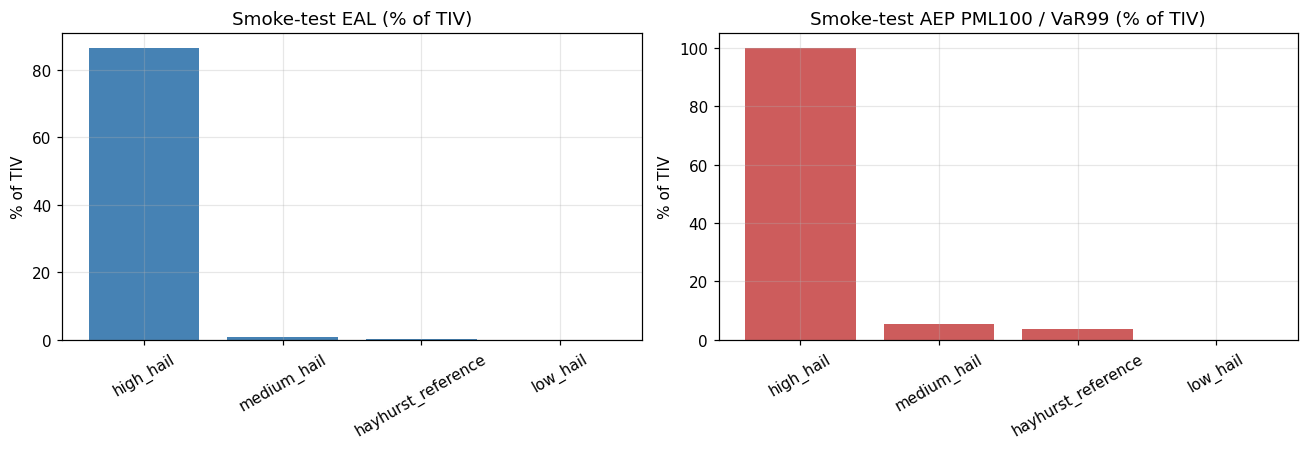

Takeaway: the pipeline produces the expected risk-metric columns, but the values inherit all M1 smoke-test caveats.


In [7]:
plot_df = metrics.sort_values("eal_pct_tiv", ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(plot_df["role"], plot_df["eal_pct_tiv"] * 100, color="steelblue")
ax[0].set(title="Smoke-test EAL (% of TIV)", ylabel="% of TIV", xlabel="")
ax[0].tick_params(axis="x", rotation=30)
ax[1].bar(plot_df["role"], plot_df["pml_aep_rp100_pct_tiv"] * 100, color="indianred")
ax[1].set(title="Smoke-test AEP PML100 / VaR99 (% of TIV)", ylabel="% of TIV", xlabel="")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
print(
    "Takeaway: the pipeline produces the expected risk-metric columns, but the values inherit all M1 smoke-test caveats."
)

## 7 - Persist small artifacts

The small CSV/JSON outputs are the useful handoff. The annual vectors are written as parquet for audit but
should remain gitignored.

In [8]:
event_cols = [
    "event_id",
    "role",
    "cell_id",
    "date",
    "footprint_area_km2_proxy",
    "cell_area_km2_proxy",
    "p_hit_solar",
    "mesh_max_mm",
    "mesh_mean_severe_mm",
    "mesh_p50_mm",
    "mesh_p90_mm",
    "mesh_p95_mm",
    "damage_ratio",
    "conditional_loss_usd",
    "conditional_loss_pct_tiv",
    "m2_coupling_basis",
    "m3_damage_basis",
]
hail_events[event_cols].to_csv(M2_EVENT_SET_CSV, index=False)
metrics.to_csv(M4_METRICS_CSV, index=False)
annual_vectors.to_parquet(M4_ANNUAL_VECTORS_PARQUET, index=False)

metadata = {
    "artifact": M4_METRICS_CSV.name,
    "status": "selected_cell_hail_solar_m2_m4_smoke_test",
    "model_version": SMOKE_VERSION,
    "hazard": "hail",
    "asset_type": "solar",
    "allowed_use": "interface smoke test for selected cells and schema validation",
    "not_allowed_use": "not final climatology; not full CONUS; not reportable EAL/PML/VaR/TVaR",
    "canonical_asset": CANONICAL_SOLAR,
    "mc_years": MC_YEARS,
    "count_model": "poisson placeholder from selected-cell M1",
    "outputs": {
        "m2_event_set": str(M2_EVENT_SET_CSV.relative_to(ROOT)),
        "m4_metrics": str(M4_METRICS_CSV.relative_to(ROOT)),
        "m4_metadata": str(M4_METRICS_JSON.relative_to(ROOT)),
        "m4_annual_vectors": str(M4_ANNUAL_VECTORS_PARQUET.relative_to(ROOT)),
    },
    "inputs": {
        "m1_layer": str(M1_LAYER_CSV.relative_to(ROOT)),
        "daily_panel": str(DAILY_PANEL_CSV.relative_to(ROOT)),
        "damage_curve": str(DAMAGE_CURVE_JSON.relative_to(ROOT)),
    },
    "caveats": [
        "MRMS Apr-Jun 2024 selected-cell pilot window only.",
        "lambda_cell is annualized from a partial hail-season window and is not final climatology.",
        "Poisson count model is a placeholder; over-dispersion is not fit here.",
        "Footprint proxy is severe native-pixel area clipped to the 0.25 degree cell.",
        "Severity uses raw daily cell-max MESH without de-biasing or EVT tail extension.",
        "Gross physical damage only; no financial terms or business interruption.",
    ],
    "qa": {
        "all_checks_pass": bool(checks["qa_checks_pass"].all()),
        "checks": checks.to_dict(orient="records"),
    },
}
M4_METRICS_JSON.write_text(json.dumps(metadata, indent=2))

print(f"wrote M2 event set: {M2_EVENT_SET_CSV}")
print(f"wrote M4 metrics: {M4_METRICS_CSV}")
print(f"wrote M4 metadata: {M4_METRICS_JSON}")
print(f"wrote annual vectors: {M4_ANNUAL_VECTORS_PARQUET}")

wrote M2 event set: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/solar/m2_solar_smoke_event_set_v2026_06_16.csv
wrote M4 metrics: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/solar/m4_solar_smoke_risk_metrics_v2026_06_16.csv
wrote M4 metadata: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/solar/m4_solar_smoke_risk_metrics_v2026_06_16.json
wrote annual vectors: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/solar/m4_solar_smoke_annual_vectors_v2026_06_16.parquet


## Findings and carried-forward

- The selected-cell M1 layer can drive a full hail x solar M2-M4 interface.
- The coupling and loss engine use the right stochastic shape: `p_hit` is a Bernoulli hit probability,
  while M3 loss is the full conditional loss on hit.
- The four-cell output contains the metric families needed by the grid schema: EAL, AEP/OEP curves,
  PML/VaR identities, TVaR, exceedance probabilities, dollars, and percent of TIV.
- The output is intentionally labeled as `selected_cell_interface_smoke_only_not_reportable`.
- Next after this: compare the Hayhurst-reference grid smoke result to the deep Hayhurst asset result as a
  sanity check, then build MRMS-only full-grid V1. Longer-record MYRORSS M1 is V1.5/V2 work.